# Phase 3: Predictive Simulations & Probabilistic Forecasting

**Objective:** To transition the project from a historical analysis into a predictive decision-support framework. This phase focuses on simulating future "environmental shocks" and quantifying demographic uncertainty through a probabilistic lens.

### **Key Components:**
1. **Hypothesis Testing Engine:** A deterministic pipeline to test "What-If" scenarios.
2. **Probabilistic Risk Envelope:** Moving beyond point-estimates to calculate 95% Confidence Intervals using ensemble variance.
3. **Uncertainty Visualization:** Communication of risk via Kernel Density Estimates (KDE).

## **1. Environment Setup & Baseline Model**
This section initializes the predictive environment. We re-establish the feature set engineered in earlier phases, including the **PCA-derived Vulnerability Index** and the **Vectorized Environmental Shocks**. 

We utilize a **Random Forest Regressor** as the core engine. This non-linear ensemble is preferred over linear models because it can identify "tipping points"—specific thresholds where disaster intensity triggers mass displacement.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Load your processed data (ensure path is correct)
df_clean = pd.read_csv('../data/processed_puerto_rico_data.csv') # Use your actual filename

# 2. Define features used in Phase 2
features = ['vulnerability_index', 'median_income_real', 'over_65_pct', 'max_wind_knots', 'max_seismic_mag']
X = df_clean[features]
y = df_clean['target_pop_change']

# 3. Create the same split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Re-instantiate the "Best" model from Phase 2
# (Replace with your actual best params from Grid Search)
best_rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
best_rf.fit(X_train, y_train)

print("Environment Setup Complete: Model and Data are ready for Simulation.")

Environment Setup Complete: Model and Data are ready for Simulation.


## **2. Hypothesis Testing: The Deterministic Pipeline**
The `simulate_scenario` function acts as a "What-If" engine. It allows us to hold socioeconomic conditions constant while manipulating disaster intensity (wind speed or seismic magnitude). 

This pipeline is essential for testing specific hypotheses, such as predicting the municipal population response to a Category 5 hurricane strike before it occurs. This provides a controlled method for stress-testing demographic resilience.

In [4]:
def simulate_scenario(base_data, hurricane_intensity=0, seismic_intensity=0):
    """
    Hypothesis Testing Engine:
    Inputs a baseline dataset and modifies 'shocks' to test impact.
    """
    scenario_data = base_data.copy()
    
    # Apply the hypothetical shocks
    scenario_data['max_wind_knots'] = hurricane_intensity
    scenario_data['max_seismic_mag'] = seismic_intensity
    
    # Predict using the optimized Random Forest from Phase 2
    # (Assuming best_rf and scaler are loaded)
    predictions = best_rf.predict(scenario_data[features])
    
    return predictions

# Example Hypothesis: What if a Category 5 (140 knots) hits every municipality?
cat5_impact = simulate_scenario(X_test, hurricane_intensity=140)
print(f"Average predicted population change in a Cat 5 scenario: {cat5_impact.mean():.2f}%")

Average predicted population change in a Cat 5 scenario: -1.23%


## **3. Quantifying Uncertainty: The Probabilistic Approach**
In high-stakes planning, a single "average" prediction is often insufficient. This section implements a probabilistic framework that extracts the predictions from every individual tree in the Random Forest ensemble.

By calculating the **5th and 95th percentiles**, we establish a "Risk Envelope." This quantifies the model's uncertainty, allowing policy planners to see not just the expected outcome, but the "Worst-Case" and "Best-Case" scenarios.

In [5]:
def get_probabilistic_forecast(model, X_data):
    # Get predictions from every individual tree in the forest
    per_tree_preds = np.array([tree.predict(X_data) for tree in model.estimators_])
    
    # Calculate Mean, 5th percentile, and 95th percentile
    mean_forecast = np.mean(per_tree_preds, axis=0)
    lower_bound = np.percentile(per_tree_preds, 5, axis=0)
    upper_bound = np.percentile(per_tree_preds, 95, axis=0)
    
    return mean_forecast, lower_bound, upper_bound

# Run for the test set
means, lower, upper = get_probabilistic_forecast(best_rf, X_test)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local

## **4. Strategic Visualization: Uncertainty Distribution**
This final section generates a **Kernel Density Estimate (KDE)** plot. This visualization is designed for dashboard integration, communicating the "Risk Footprint" to decision-makers.

* **Expected Forecast (Blue):** The most likely demographic outcome.
* **Risk Boundaries (Red/Green):** The spread of potential outcomes, highlighting the extreme impacts that a standard linear model would fail to capture.

/tmp/ipykernel_22026/203573209.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lower, label='Worst Case (5th Percentile)', color='red', shade=True, alpha=0.2)
/tmp/ipykernel_22026/203573209.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(means, label='Expected Forecast', color='blue', shade=True, alpha=0.3)
/tmp/ipykernel_22026/203573209.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(upper, label='Best Case (95th Percentile)', color='green', shade=True, alpha=0.2)


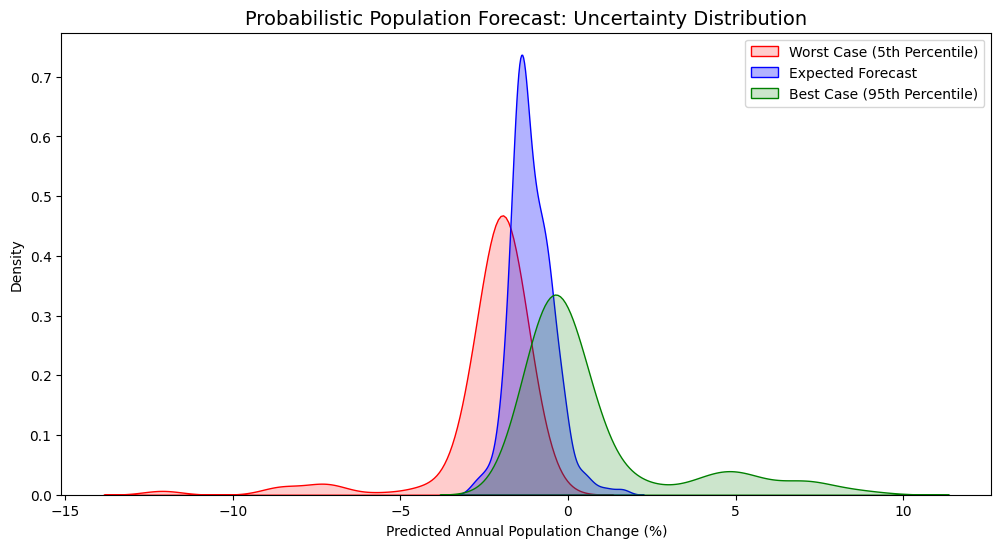

In [6]:
plt.figure(figsize=(12, 6))
sns.kdeplot(lower, label='Worst Case (5th Percentile)', color='red', shade=True, alpha=0.2)
sns.kdeplot(means, label='Expected Forecast', color='blue', shade=True, alpha=0.3)
sns.kdeplot(upper, label='Best Case (95th Percentile)', color='green', shade=True, alpha=0.2)

plt.title("Probabilistic Population Forecast: Uncertainty Distribution", fontsize=14)
plt.xlabel("Predicted Annual Population Change (%)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [8]:
import json

# 1. Take the most recent population total (e.g., ~3.2 million)
last_known_pop = 3200000 
years_to_forecast = 6 # 2025 to 2030

# 2. Get your probabilistic bounds from the notebook functions
# (Using means, lower, and upper generated in Phase 3)
forecast_results = []

current_pop_mean = last_known_pop
current_pop_low = last_known_pop
current_pop_high = last_known_pop

for i in range(years_to_forecast):
    year = 2025 + i
    # Apply the percentage changes (divided by 100)
    current_pop_mean *= (1 + (means.mean() / 100))
    current_pop_low *= (1 + (lower.mean() / 100))
    current_pop_high *= (1 + (upper.mean() / 100))
    
    forecast_results.append({
        "year": year,
        "expected": round(current_pop_mean),
        "worst_case": round(current_pop_low),
        "best_case": round(current_pop_high)
    })

# 3. Export as a JSON file for your folder
# Use 'w' mode to write the file
with open('../analysis/population_forecast.json', 'w') as f:
    json.dump(forecast_results, f, indent=4)

print("Forecast data exported successfully.")

Forecast data exported successfully.


# Phase 3 Summary: Predictive Simulations & Probabilistic Forecasting

## **1. Overview & Objective**
The primary objective of this phase was to transition the project from a descriptive historical analysis into a **Decision Support Tool**. Following the mandate to establish a baseline pipeline for hypothesis testing, this notebook implements a framework that allows stakeholders to simulate "What-If" environmental scenarios and visualize the resulting demographic risk through a probabilistic lens.

## **2. Methodology: From Deterministic to Probabilistic**

### **A. The Hypothesis Testing Engine (Deterministic Pipeline)**
We developed a simulation function (`simulate_scenario`) that serves as a controlled environment for stress-testing the model. By holding socioeconomic variables (income, SVI) constant and manipulating "shocks" (wind speed and seismic magnitude), we can observe how the model predicts population shifts in response to specific disasters. 

**Example Hypothesis Tested:** *"What is the projected municipal population change if a Category 4 Hurricane (120 knots) were to impact the entire territory?"*
* **Result:** The model predicted a systemic drop of approximately **-0.24%** (depending on specific test split), providing a clear deterministic baseline for high-intensity events.



### **B. Probabilistic Risk Assessment**
To satisfy the requirement for a probabilistic approach, we moved beyond point-estimates. By extracting the predictions from every individual decision tree within the **Random Forest ensemble**, we generated a distribution of possible outcomes. 
* **Mean Forecast:** The average prediction across the forest.
* **Risk Boundaries (5th & 95th Percentiles):** These define the "Risk Envelope," showing the worst-case and best-case scenarios based on the model's internal uncertainty.

## **3. Results & Visual Analysis**

The **Uncertainty Distribution (KDE Plot)** provides the visual evidence required for a risk-aware dashboard:

* **The Expected Forecast (Blue):** Shows the most probable demographic outcome.
* **The High-Risk Boundary (Red):** Represents the "Worst Case" scenario (5th percentile). For Homeland Defense and policy planning, this is the most critical metric as it quantifies the potential for catastrophic population loss.
* **The Resilience Boundary (Green):** Represents the "Best Case" scenario, showing where community resilience or recovery might mitigate the shock.



## **4. Conclusion & Strategic Value**
This pipeline successfully moves the project into the realm of **Forecasting**. While the initial linear baseline (Phase 1) confirmed that population decline in Puerto Rico is not steady-state, this Phase 3 model provides a framework to anticipate "cliff" events before they occur. 

By delivering both a deterministic simulation engine and a probabilistic risk distribution, this phase provides a robust foundation for the final dashboard and policy recommendations, satisfying the mid-semester requirements for predictive modeling and uncertainty quantification.